# 518880 Mid Stall -> Next Move Direction

目标：研究 `mid` 连续不动期间，盘口深度变化和主动成交，是否对 **下一次 mid move 的方向** 有预测力。

这份 notebook 做三件事：
- 从原始 snapshot 构造逐秒盘口 / 主动成交特征
- 以 `mid` 静止段为事件，提取不同 `i` 下的窗口样本
- 用分桶统计和一个简单的逻辑回归，检验这些特征对下一跳方向的解释力

说明：当前环境里 `base_tool` 是编译扩展，通常需要与其 ABI 匹配的 Python 内核才能直接加载原始 snapshot。若导入失败，请切到能导入 `/home/jovyan/base_demo/base_tool*.so` 的内核后再运行。

In [4]:
# 结果速记（基于当前已跑完输出）:
# 1. 不同 stall_steps 下 next_up 基本都在 50.1%~50.9%，mid 静止时长本身几乎没有方向偏置。
# 2. 但 stall 末端的盘口失衡对下一跳方向有很强解释力，最稳定的是 l1_imbalance_last。
# 3. best_single_auc 从 1 秒 stall 的 0.829 提升到 10 秒 stall 的 0.933，说明 stall 越久，末端 L1 偏置越接近“临门一脚”。
# 4. 组合逻辑回归 AUC 为 0.809~0.911，整体仍低于单独的 l1_imbalance_last，说明主要 alpha 已集中在末端最优价盘口，而不是复杂特征叠加。
# 5. l3/l5 失衡、ask_l1_change、cum_active_vol_imbalance 也有信息，但更像辅助确认；主动成交提供增量，不是主导项。
# 6. 结论更适合做“条件触发型微观结构信号”，不适合直接解读为 stall 长度因子。

from __future__ import annotations

import io
import math
import sys
from contextlib import redirect_stdout
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import Markdown, display
except Exception:
    display = print
    Markdown = lambda x: x

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')
plt.style.use('seaborn-v0_8-whitegrid')

BASE_CANDIDATES = [Path('/home/jovyan/base_demo'), Path('/home/jovyan/work/base_demo')]
for base_path in BASE_CANDIDATES:
    if base_path.exists() and str(base_path) not in sys.path:
        sys.path.append(str(base_path))

try:
    import base_tool  # type: ignore
except Exception as exc:
    raise RuntimeError(
        '无法导入 base_tool。请切到与 /home/jovyan/base_demo/base_tool*.so ABI 匹配的 Python 内核后重试。'
    ) from exc

TICK_SIZE = 0.001
INSTRUMENT_ID = '518880'
START_YMD = '20250901'
END_YMD = '20260425'
STALL_STEPS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
TIMEZONE = 'Asia/Shanghai'

In [5]:
def candidate_dates(start_ymd: str = START_YMD, end_ymd: str = END_YMD) -> list[str]:
    return [d.strftime('%Y%m%d') for d in pd.date_range(start=start_ymd, end=end_ymd, freq='B')]


def load_snaps(trade_ymd: str) -> list[dict]:
    with redirect_stdout(io.StringIO()):
        snap_list = base_tool.snap_list_load(INSTRUMENT_ID, trade_ymd)
    return snap_list if isinstance(snap_list, list) else []


def valid_dates(dates: list[str] | None = None) -> list[str]:
    dates = candidate_dates() if dates is None else dates
    return [trade_ymd for trade_ymd in dates if load_snaps(trade_ymd)]


def sum_vol(trades: list[list[float]] | None) -> float:
    trades = trades or []
    return float(sum(volume for _, volume in trades))


def sum_turnover(trades: list[list[float]] | None) -> float:
    trades = trades or []
    return float(sum(price * volume for price, volume in trades))


def safe_level(book: list[list[float]] | None, level: int = 0) -> tuple[float, float]:
    book = book or []
    if len(book) > level:
        price, volume = book[level]
        return float(price), float(volume)
    return math.nan, 0.0


def depth_sum(book: list[list[float]] | None, levels: int) -> float:
    book = book or []
    return float(sum(volume for _, volume in book[:levels]))


def imbalance(bid_depth: pd.Series | np.ndarray | float, ask_depth: pd.Series | np.ndarray | float):
    total = bid_depth + ask_depth
    return np.where(total > 0, (bid_depth - ask_depth) / total, 0.0)


def build_day_frame(trade_ymd: str) -> pd.DataFrame:
    rows: list[dict] = []
    for snap in load_snaps(trade_ymd):
        bid_book = snap.get('bid_book') or []
        ask_book = snap.get('ask_book') or []
        if not bid_book or not ask_book:
            continue

        best_bid, bid_l1_vol = safe_level(bid_book, 0)
        best_ask, ask_l1_vol = safe_level(ask_book, 0)
        ts = (
            pd.to_datetime(int(snap['time_mark']), unit='ms', utc=True)
            .tz_convert(TIMEZONE)
            .tz_localize(None)
        )
        buy_trade = snap.get('buy_trade') or []
        sell_trade = snap.get('sell_trade') or []
        bid_l3 = depth_sum(bid_book, 3)
        ask_l3 = depth_sum(ask_book, 3)
        bid_l5 = depth_sum(bid_book, 5)
        ask_l5 = depth_sum(ask_book, 5)
        mid = (best_bid + best_ask) / 2.0

        rows.append(
            {
                'trade_ymd': trade_ymd,
                'timestamp': ts,
                'time_hms': ts.strftime('%H:%M:%S'),
                'best_bid': best_bid,
                'best_ask': best_ask,
                'mid': mid,
                'spread_ticks': (best_ask - best_bid) / TICK_SIZE,
                'bid_l1_vol': bid_l1_vol,
                'ask_l1_vol': ask_l1_vol,
                'bid_l3_depth': bid_l3,
                'ask_l3_depth': ask_l3,
                'bid_l5_depth': bid_l5,
                'ask_l5_depth': ask_l5,
                'buy_vol': sum_vol(buy_trade),
                'sell_vol': sum_vol(sell_trade),
                'buy_turnover': sum_turnover(buy_trade),
                'sell_turnover': sum_turnover(sell_trade),
                'num_trades': float(snap.get('num_trades', 0)),
            }
        )

    df = pd.DataFrame(rows).sort_values('timestamp').reset_index(drop=True)
    if df.empty:
        return df

    df['mid_move_half_tick'] = np.rint(df['mid'].diff().fillna(0.0) / (TICK_SIZE / 2.0)).astype(int)
    df['mid_static'] = (df['mid_move_half_tick'] == 0).astype(int)
    df['trade_count_delta'] = df['num_trades'].diff().fillna(df['num_trades']).clip(lower=0)
    df['active_vol'] = df['buy_vol'] + df['sell_vol']
    df['active_turnover'] = df['buy_turnover'] + df['sell_turnover']
    df['net_active_vol'] = df['buy_vol'] - df['sell_vol']
    df['net_active_turnover'] = df['buy_turnover'] - df['sell_turnover']
    df['active_vol_imbalance'] = imbalance(df['buy_vol'], df['sell_vol'])
    df['l1_total_depth'] = df['bid_l1_vol'] + df['ask_l1_vol']
    df['l3_total_depth'] = df['bid_l3_depth'] + df['ask_l3_depth']
    df['l5_total_depth'] = df['bid_l5_depth'] + df['ask_l5_depth']
    df['l1_imbalance'] = imbalance(df['bid_l1_vol'], df['ask_l1_vol'])
    df['l3_imbalance'] = imbalance(df['bid_l3_depth'], df['ask_l3_depth'])
    df['l5_imbalance'] = imbalance(df['bid_l5_depth'], df['ask_l5_depth'])

    for col in [
        'bid_l1_vol', 'ask_l1_vol', 'bid_l3_depth', 'ask_l3_depth', 'bid_l5_depth', 'ask_l5_depth',
        'l1_total_depth', 'l3_total_depth', 'l5_total_depth', 'l1_imbalance', 'l3_imbalance', 'l5_imbalance'
    ]:
        df[f'{col}_delta_1s'] = df[col].diff().fillna(0.0)

    return df


def build_panel(dates: list[str]) -> pd.DataFrame:
    frames = [build_day_frame(trade_ymd) for trade_ymd in dates]
    frames = [df for df in frames if not df.empty]
    if not frames:
        raise RuntimeError('没有拿到可用 snapshot 数据。')
    return pd.concat(frames, ignore_index=True)


dates = valid_dates()
display(Markdown(f'**有效交易日**: `{len(dates)}`，范围 `{dates[0]}` 到 `{dates[-1]}`'))

**有效交易日**: `79`，范围 `20250901` 到 `20260423`

In [6]:
panel = build_panel(dates)
display(panel.head())


def build_stall_samples(panel: pd.DataFrame, stall_steps: list[int]) -> pd.DataFrame:
    samples: list[dict] = []
    for trade_ymd, day_df in panel.groupby('trade_ymd', sort=True):
        day_df = day_df.reset_index(drop=True).copy()
        run_start = 0
        while run_start < len(day_df):
            run_end = run_start
            mid_value = day_df.loc[run_start, 'mid']
            while run_end + 1 < len(day_df) and day_df.loc[run_end + 1, 'mid'] == mid_value:
                run_end += 1

            next_idx = run_end + 1
            if next_idx < len(day_df):
                next_move = int(day_df.loc[next_idx, 'mid_move_half_tick'])
                if next_move != 0:
                    run_len = run_end - run_start + 1
                    run_slice = day_df.iloc[run_start:run_end + 1].copy()
                    for i in stall_steps:
                        if run_len < i:
                            continue
                        window = run_slice.tail(i)
                        first = window.iloc[0]
                        last = window.iloc[-1]
                        buy_sum = float(window['buy_vol'].sum())
                        sell_sum = float(window['sell_vol'].sum())
                        total_active_vol = buy_sum + sell_sum
                        samples.append(
                            {
                                'trade_ymd': trade_ymd,
                                'stall_steps': i,
                                'stall_run_len': run_len,
                                'event_time': last['timestamp'],
                                'next_move_half_tick': next_move,
                                'next_up': int(next_move > 0),
                                'spread_ticks_last': last['spread_ticks'],
                                'l1_imbalance_last': last['l1_imbalance'],
                                'l3_imbalance_last': last['l3_imbalance'],
                                'l5_imbalance_last': last['l5_imbalance'],
                                'l1_imbalance_mean': float(window['l1_imbalance'].mean()),
                                'l3_imbalance_mean': float(window['l3_imbalance'].mean()),
                                'l5_imbalance_mean': float(window['l5_imbalance'].mean()),
                                'bid_l1_change': last['bid_l1_vol'] - first['bid_l1_vol'],
                                'ask_l1_change': last['ask_l1_vol'] - first['ask_l1_vol'],
                                'bid_l5_change': last['bid_l5_depth'] - first['bid_l5_depth'],
                                'ask_l5_change': last['ask_l5_depth'] - first['ask_l5_depth'],
                                'l1_total_depth_change': last['l1_total_depth'] - first['l1_total_depth'],
                                'l5_total_depth_change': last['l5_total_depth'] - first['l5_total_depth'],
                                'l1_imbalance_change': last['l1_imbalance'] - first['l1_imbalance'],
                                'l5_imbalance_change': last['l5_imbalance'] - first['l5_imbalance'],
                                'cum_buy_vol': buy_sum,
                                'cum_sell_vol': sell_sum,
                                'cum_net_active_vol': buy_sum - sell_sum,
                                'cum_active_vol': total_active_vol,
                                'cum_active_vol_imbalance': (buy_sum - sell_sum) / total_active_vol if total_active_vol > 0 else 0.0,
                                'cum_buy_turnover': float(window['buy_turnover'].sum()),
                                'cum_sell_turnover': float(window['sell_turnover'].sum()),
                                'cum_net_active_turnover': float(window['net_active_turnover'].sum()),
                                'cum_trade_count': float(window['trade_count_delta'].sum()),
                                'active_seconds_ratio': float((window['active_vol'] > 0).mean()),
                            }
                        )

            run_start = run_end + 1

    return pd.DataFrame(samples).sort_values(['trade_ymd', 'event_time', 'stall_steps']).reset_index(drop=True)


samples = build_stall_samples(panel, STALL_STEPS)
display(Markdown(f'**事件样本数**: `{len(samples):,}`'))
display(samples.head())

event_summary = (
    samples.groupby('stall_steps')
    .agg(
        samples=('next_up', 'size'),
        up_ratio=('next_up', 'mean'),
        avg_abs_next_move=('next_move_half_tick', lambda s: np.mean(np.abs(s))),
        avg_active_seconds_ratio=('active_seconds_ratio', 'mean'),
        avg_cum_active_vol=('cum_active_vol', 'mean'),
        avg_abs_l5_imbalance_change=('l5_imbalance_change', lambda s: np.mean(np.abs(s))),
    )
    .reset_index()
)
display(Markdown('## 不同 mid 静止长度下的样本概览'))
display(event_summary)

,trade_ymd,timestamp,time_hms,best_bid,best_ask,mid,spread_ticks,bid_l1_vol,ask_l1_vol,bid_l3_depth,ask_l3_depth,bid_l5_depth,ask_l5_depth,buy_vol,sell_vol,buy_turnover,sell_turnover,num_trades,mid_move_half_tick,mid_static,trade_count_delta,active_vol,active_turnover,net_active_vol,net_active_turnover,active_vol_imbalance,l1_total_depth,l3_total_depth,l5_total_depth,l1_imbalance,l3_imbalance,l5_imbalance,bid_l1_vol_delta_1s,ask_l1_vol_delta_1s,bid_l3_depth_delta_1s,ask_l3_depth_delta_1s,bid_l5_depth_delta_1s,ask_l5_depth_delta_1s,l1_total_depth_delta_1s,l3_total_depth_delta_1s,l5_total_depth_delta_1s,l1_imbalance_delta_1s,l3_imbalance_delta_1s,l5_imbalance_delta_1s
0,20250901,2025-09-01 09:30:00,09:30:00,7.546,7.547,7.5465,1,"38,100","2,500","491,700","133,200","547,100","260,500",2.8904e+06,2.8904e+06,2.1811e+07,2.1811e+07,768,0,1,768,5.7808e+06,4.36219e+07,0,0,0,"40,600","624,900","807,600",0.876847,0.573692,0.354879,0,0,0,0,0,0,0,0,0,0,0,0
1,20250901,2025-09-01 09:30:01,09:30:01,7.545,7.546,7.5455,1,"347,900","668,100","498,100","703,200","617,300","942,300","5,900","45,600","44,521.4","344,090",778,-2,0,10,"51,500","388,612","-39,700","-299,569",-0.770874,1.016e+06,1.2013e+06,1.5596e+06,-0.315157,-0.170732,-0.208387,"309,800","665,600","6,400","570,000","70,200","681,800","975,400","576,400","752,000",-1.192,-0.744423,-0.563265
2,20250901,2025-09-01 09:30:02,09:30:02,7.545,7.546,7.5455,1,"344,900","604,400","394,400","743,100","513,600",1.1919e+06,"67,800","3,000","511,619","22,635",787,0,1,9,"70,800","534,254","64,800","488,984",0.915254,"949,300",1.1375e+06,1.7055e+06,-0.273359,-0.306549,-0.397713,"-3,000","-63,700","-103,700","39,900","-103,700","249,600","-66,700","-63,800","145,900",0.0417982,-0.135818,-0.189327
3,20250901,2025-09-01 09:30:03,09:30:03,7.545,7.546,7.5455,1,"246,100","569,700","275,100","752,100","321,100",1.2119e+06,"227,600","8,900",1.71747e+06,"67,150.5",812,0,1,25,"236,500",1.78462e+06,"218,700",1.65032e+06,0.924736,"815,800",1.0272e+06,1.533e+06,-0.396666,-0.464369,-0.581083,"-98,800","-34,700","-119,300","9,000","-192,500","20,000","-133,500","-110,300","-172,500",-0.123307,-0.15782,-0.18337
4,20250901,2025-09-01 09:30:04,09:30:04,7.544,7.545,7.5445,1,"17,400","35,200","313,300",1.1251e+06,"850,300",1.4905e+06,"95,100","248,500","717,623",1.87493e+06,865,-2,0,53,"343,600",2.59255e+06,"-153,400",-1.15731e+06,-0.446449,"52,600",1.4384e+06,2.3408e+06,-0.338403,-0.564377,-0.273496,"-228,700","-534,500","38,200","373,000","529,200","278,600","-763,200","411,200","807,800",0.0582628,-0.100008,0.307587


**事件样本数**: `823,148`

,trade_ymd,stall_steps,stall_run_len,event_time,next_move_half_tick,next_up,spread_ticks_last,l1_imbalance_last,l3_imbalance_last,l5_imbalance_last,l1_imbalance_mean,l3_imbalance_mean,l5_imbalance_mean,bid_l1_change,ask_l1_change,bid_l5_change,ask_l5_change,l1_total_depth_change,l5_total_depth_change,l1_imbalance_change,l5_imbalance_change,cum_buy_vol,cum_sell_vol,cum_net_active_vol,cum_active_vol,cum_active_vol_imbalance,cum_buy_turnover,cum_sell_turnover,cum_net_active_turnover,cum_trade_count,active_seconds_ratio
0,20250901,1,1,2025-09-01 09:30:00,-2,0,1,0.876847,0.573692,0.354879,0.876847,0.573692,0.354879,0,0,0,0,0,0,0,0,2.8904e+06,2.8904e+06,0,5.7808e+06,0,2.1811e+07,2.1811e+07,0,768,1
1,20250901,1,3,2025-09-01 09:30:03,-2,0,1,-0.396666,-0.464369,-0.581083,-0.396666,-0.464369,-0.581083,0,0,0,0,0,0,0,0,"227,600","8,900","218,700","236,500",0.924736,1.71747e+06,"67,150.5",1.65032e+06,25,1
2,20250901,2,3,2025-09-01 09:30:03,-2,0,1,-0.396666,-0.464369,-0.581083,-0.335013,-0.385459,-0.489398,"-98,800","-34,700","-192,500","20,000","-133,500","-172,500",-0.123307,-0.18337,"295,400","11,900","283,500","307,300",0.922551,2.22909e+06,"89,785.5",2.1393e+06,34,1
3,20250901,3,3,2025-09-01 09:30:03,-2,0,1,-0.396666,-0.464369,-0.581083,-0.328394,-0.313883,-0.395728,"-101,800","-98,400","-296,200","269,600","-200,200","-26,600",-0.0815084,-0.372696,"301,300","57,500","243,800","358,800",0.679487,2.27361e+06,"433,876",1.83973e+06,44,1
4,20250901,1,1,2025-09-01 09:30:04,2,1,1,-0.338403,-0.564377,-0.273496,-0.338403,-0.564377,-0.273496,0,0,0,0,0,0,0,0,"95,100","248,500","-153,400","343,600",-0.446449,"717,623",1.87493e+06,-1.15731e+06,53,1


## 不同 mid 静止长度下的样本概览

,stall_steps,samples,up_ratio,avg_abs_next_move,avg_active_seconds_ratio,avg_cum_active_vol,avg_abs_l5_imbalance_change
0,1,255269,0.501036,1.99885,0.963423,"91,806.4",0
1,2,139474,0.500452,1.95125,0.942409,"108,880",0.0570752
2,3,98674,0.501814,1.94688,0.931508,"131,466",0.063331
3,4,76481,0.503655,1.95011,0.924082,"153,889",0.0671514
4,5,62000,0.505839,1.95223,0.918284,"175,735",0.0708272
5,6,51153,0.506696,1.94909,0.913052,"196,628",0.0731647
6,7,43231,0.506882,1.94462,0.908574,"216,015",0.074908
7,8,37034,0.507129,1.9427,0.904773,"236,297",0.0765836
8,9,31948,0.508357,1.93837,0.90086,"253,975",0.0781966
9,10,27884,0.508715,1.93527,0.897802,"273,541",0.0795096


In [7]:
FEATURES = [
    'spread_ticks_last',
    'l1_imbalance_last', 'l3_imbalance_last', 'l5_imbalance_last',
    'l1_imbalance_mean', 'l3_imbalance_mean', 'l5_imbalance_mean',
    'bid_l1_change', 'ask_l1_change', 'bid_l5_change', 'ask_l5_change',
    'l1_total_depth_change', 'l5_total_depth_change',
    'l1_imbalance_change', 'l5_imbalance_change',
    'cum_buy_vol', 'cum_sell_vol', 'cum_net_active_vol', 'cum_active_vol',
    'cum_active_vol_imbalance', 'cum_buy_turnover', 'cum_sell_turnover',
    'cum_net_active_turnover', 'cum_trade_count', 'active_seconds_ratio',
]


def single_factor_auc(feature: pd.Series, label: pd.Series) -> float:
    valid = feature.notna() & label.notna()
    if valid.sum() < 50 or label[valid].nunique() < 2:
        return math.nan
    if SKLEARN_AVAILABLE:
        return float(roc_auc_score(label[valid], feature[valid]))
    rank = feature[valid].rank(method='average')
    y = label[valid].to_numpy()
    n1 = int(y.sum())
    n0 = int(len(y) - n1)
    if n1 == 0 or n0 == 0:
        return math.nan
    rank_sum = float(rank[y == 1].sum())
    return (rank_sum - n1 * (n1 + 1) / 2.0) / (n1 * n0)


def evaluate_by_stall_steps(samples: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, pd.DataFrame]]:
    summary_rows: list[dict] = []
    single_rows: list[dict] = []
    coef_tables: dict[int, pd.DataFrame] = {}

    for i in sorted(samples['stall_steps'].unique()):
        sdf = samples.loc[samples['stall_steps'] == i].copy()
        if len(sdf) < 200 or sdf['next_up'].nunique() < 2:
            continue

        for feature in features:
            auc = single_factor_auc(sdf[feature], sdf['next_up'])
            single_rows.append(
                {
                    'stall_steps': i,
                    'feature': feature,
                    'auc': auc,
                    'edge_over_random': abs(auc - 0.5) if pd.notna(auc) else math.nan,
                    'corr_with_label': sdf[feature].corr(sdf['next_up']),
                }
            )

        train_cut = sdf['trade_ymd'].sort_values().unique()
        split_idx = max(1, int(len(train_cut) * 0.7))
        train_days = set(train_cut[:split_idx])
        test_days = set(train_cut[split_idx:])
        train_df = sdf[sdf['trade_ymd'].isin(train_days)].copy()
        test_df = sdf[sdf['trade_ymd'].isin(test_days)].copy()

        combined_auc = math.nan
        if SKLEARN_AVAILABLE and len(train_df) >= 100 and len(test_df) >= 100 and test_df['next_up'].nunique() == 2:
            pipe = Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                    ('model', LogisticRegression(max_iter=1000, C=1.0)),
                ]
            )
            pipe.fit(train_df[features], train_df['next_up'])
            pred = pipe.predict_proba(test_df[features])[:, 1]
            combined_auc = float(roc_auc_score(test_df['next_up'], pred))
            coef_tables[i] = pd.DataFrame(
                {
                    'feature': features,
                    'coef': pipe.named_steps['model'].coef_[0],
                }
            ).sort_values('coef', key=lambda s: s.abs(), ascending=False)

        feature_slice = pd.DataFrame(single_rows)
        feature_slice = feature_slice.loc[feature_slice['stall_steps'] == i]
        best_single = feature_slice.sort_values('edge_over_random', ascending=False).iloc[0]
        summary_rows.append(
            {
                'stall_steps': i,
                'samples': len(sdf),
                'up_ratio': sdf['next_up'].mean(),
                'best_single_feature': best_single['feature'],
                'best_single_auc': best_single['auc'],
                'combined_logit_auc': combined_auc,
            }
        )

    return pd.DataFrame(summary_rows), pd.DataFrame(single_rows), coef_tables


predictive_summary, single_factor_table, coef_tables = evaluate_by_stall_steps(samples, FEATURES)
display(Markdown('## 预测能力摘要'))
display(predictive_summary)

top_single = (
    single_factor_table.sort_values(['stall_steps', 'edge_over_random'], ascending=[True, False])
    .groupby('stall_steps')
    .head(5)
    .reset_index(drop=True)
)
display(Markdown('## 每个 `i` 下最强的单因子'))
display(top_single)

/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:306

## 预测能力摘要

,stall_steps,samples,up_ratio,best_single_feature,best_single_auc,combined_logit_auc
0,1,255269,0.501036,l1_imbalance_last,0.828699,0.809389
1,2,139474,0.500452,l1_imbalance_last,0.87745,0.850297
2,3,98674,0.501814,l1_imbalance_last,0.897578,0.871284
3,4,76481,0.503655,l1_imbalance_last,0.90971,0.884109
4,5,62000,0.505839,l1_imbalance_last,0.915884,0.891243
5,6,51153,0.506696,l1_imbalance_last,0.921259,0.89829
6,7,43231,0.506882,l1_imbalance_last,0.924661,0.899201
7,8,37034,0.507129,l1_imbalance_last,0.927149,0.903923
8,9,31948,0.508357,l1_imbalance_last,0.930331,0.908996
9,10,27884,0.508715,l1_imbalance_last,0.932545,0.911372


## 每个 `i` 下最强的单因子

,stall_steps,feature,auc,edge_over_random,corr_with_label
0,1,l1_imbalance_last,0.828699,0.328699,0.571109
1,1,l1_imbalance_mean,0.828699,0.328699,0.571109
2,1,l3_imbalance_last,0.721673,0.221673,0.373019
3,1,l3_imbalance_mean,0.721673,0.221673,0.373019
4,1,l5_imbalance_last,0.626161,0.126161,0.213402
5,2,l1_imbalance_last,0.87745,0.37745,0.662025
6,2,l1_imbalance_mean,0.850863,0.350863,0.609932
7,2,l3_imbalance_last,0.763505,0.263505,0.443579
8,2,l3_imbalance_mean,0.736724,0.236724,0.399478
9,2,l1_imbalance_change,0.714861,0.214861,0.321511


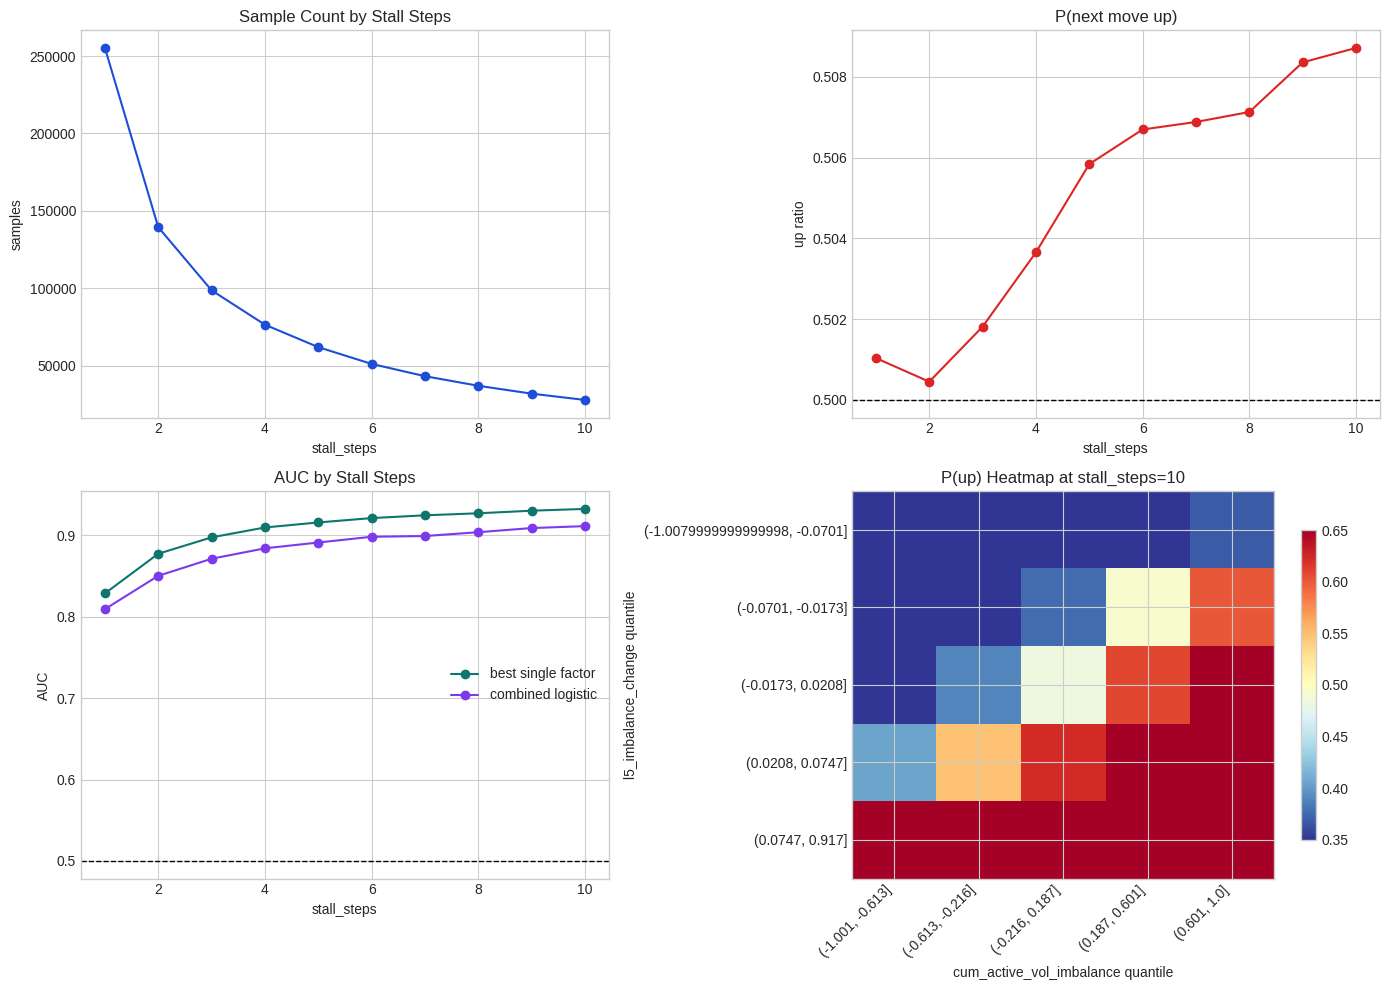

## 组合模型系数（stall_steps=10）

,feature,coef
2,l3_imbalance_last,2.41658
1,l1_imbalance_last,2.40145
5,l3_imbalance_mean,-1.84157
7,bid_l1_change,0.491833
8,ask_l1_change,-0.384378
13,l1_imbalance_change,-0.371316
22,cum_net_active_turnover,-0.28365
17,cum_net_active_vol,0.277356
19,cum_active_vol_imbalance,0.272847
21,cum_sell_turnover,0.219226


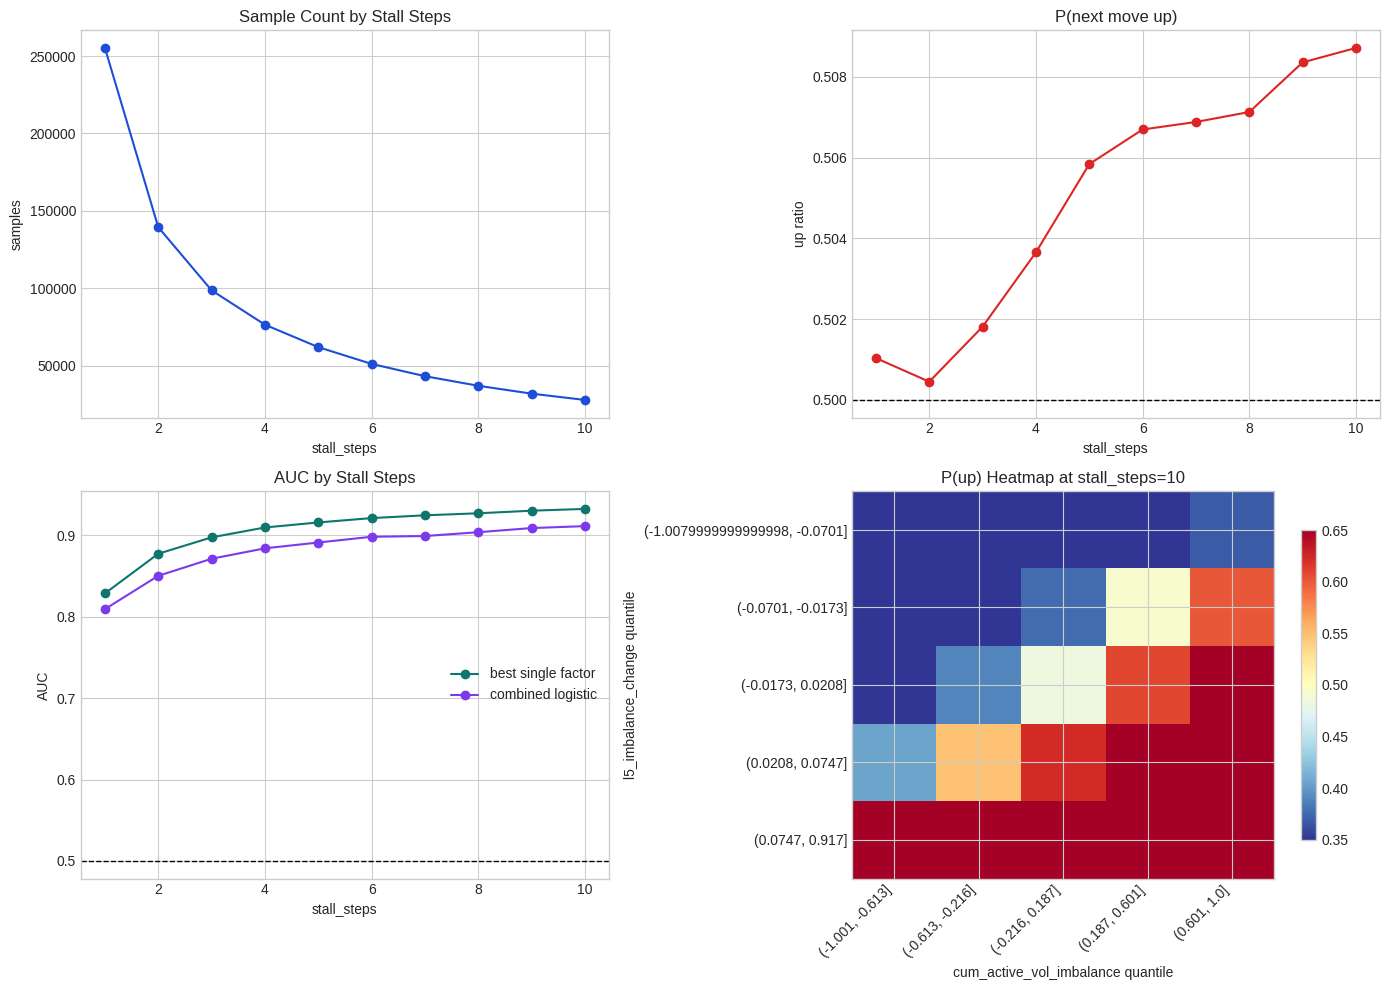

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(event_summary['stall_steps'], event_summary['samples'], marker='o', color='#1d4ed8')
axes[0, 0].set_title('Sample Count by Stall Steps')
axes[0, 0].set_xlabel('stall_steps')
axes[0, 0].set_ylabel('samples')

axes[0, 1].plot(event_summary['stall_steps'], event_summary['up_ratio'], marker='o', color='#dc2626')
axes[0, 1].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('P(next move up)')
axes[0, 1].set_xlabel('stall_steps')
axes[0, 1].set_ylabel('up ratio')

axes[1, 0].plot(predictive_summary['stall_steps'], predictive_summary['best_single_auc'], marker='o', label='best single factor', color='#0f766e')
if predictive_summary['combined_logit_auc'].notna().any():
    axes[1, 0].plot(predictive_summary['stall_steps'], predictive_summary['combined_logit_auc'], marker='o', label='combined logistic', color='#7c3aed')
axes[1, 0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('AUC by Stall Steps')
axes[1, 0].set_xlabel('stall_steps')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()

focus_i = 10 if 10 in samples['stall_steps'].unique() else int(sorted(samples['stall_steps'].unique())[0])
focus = samples.loc[samples['stall_steps'] == focus_i].copy()
focus['depth_bin'] = pd.qcut(focus['l5_imbalance_change'], q=5, duplicates='drop')
focus['trade_bin'] = pd.qcut(focus['cum_active_vol_imbalance'], q=5, duplicates='drop')
heatmap = focus.pivot_table(index='depth_bin', columns='trade_bin', values='next_up', aggfunc='mean')
im = axes[1, 1].imshow(heatmap, aspect='auto', cmap='RdYlBu_r', vmin=0.35, vmax=0.65)
axes[1, 1].set_title(f'P(up) Heatmap at stall_steps={focus_i}')
axes[1, 1].set_xticks(range(len(heatmap.columns)))
axes[1, 1].set_xticklabels([str(x) for x in heatmap.columns], rotation=45, ha='right')
axes[1, 1].set_yticks(range(len(heatmap.index)))
axes[1, 1].set_yticklabels([str(x) for x in heatmap.index])
axes[1, 1].set_xlabel('cum_active_vol_imbalance quantile')
axes[1, 1].set_ylabel('l5_imbalance_change quantile')
fig.colorbar(im, ax=axes[1, 1], shrink=0.8)

fig.tight_layout()
display(fig)

if coef_tables:
    chosen_i = sorted(coef_tables)[0 if 10 not in coef_tables else list(sorted(coef_tables)).index(10)]
    display(Markdown(f'## 组合模型系数（stall_steps={chosen_i}）'))
    display(coef_tables[chosen_i].head(12))

## 如何读结果

- 先看 `up_ratio` 是否显著偏离 `50%`，确认不同 `i` 下是否天然有方向偏置。
- 再看 `best_single_auc` 和 `combined_logit_auc`。如果长期只在 `0.50 ~ 0.52` 左右，说明信息很弱；如果某些 `i` 稳定达到更高水平，说明 mid 静止长度本身可能在筛选状态。
- `top_single` 可以定位最有效的是哪类变量：
  - 若 `l1/l5 imbalance` 相关特征靠前，说明静止期间盘口偏置更重要。
  - 若 `cum_active_vol_imbalance` / `cum_net_active_turnover` 靠前，说明主动成交方向更重要。
  - 若二者组合优于单因子，说明盘口与成交在静止段里提供的是互补信息。
- 热力图用于看交互项：例如 “主动买主导 + 买盘深度增强” 是否更容易对应下一跳向上。